---

### <center> 기본 세팅

---

In [60]:
import os 
import sys
import requests
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   
import math
import scipy.stats as stats
from io import StringIO
from datetime import datetime, timedelta

import warnings 
warnings.filterwarnings("ignore")

In [61]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:
    
    plt.rc('font', family='NanumGothic')

# 마이너스 기호방지
plt.rcParams['axes.unicode_minus'] = False

In [62]:
# 데이터 저장후 parquet 변환
# articles = pd.read_csv(r'../Data Folder/H&M dataset/articles.csv', dtype={'article_id': str})
# customers = pd.read_csv(r'../Data Folder/H&M dataset/customers.csv')
# transactions = pd.read_csv(r'../Data Folder/H&M dataset/transactions_train.csv', 
#                            dtype={'article_id': str, 'customer_id': str},
#                            parse_dates=['t_dat']) # 미리 파싱
# sample_submission = pd.read_csv('../Data Folder/H&M dataset/sample_submission.csv', 
                                # dtype={'customer_id': str, 'prediction': str})

# articles.to_parquet('articles.parquet', engine='fastparquet')
# customers.to_parquet('customers.parquet', engine='fastparquet')
# transactions.to_parquet('transactions.parquet', engine='fastparquet')
# sample_submission.to_parquet('sample_submission.parquet', engine='pyarrow', index=False)

# print("=== 변환 확인 ===")

In [63]:
# 불러오기
articles = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/articles.parquet')
customers = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/customers.parquet')
transactions = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/transactions.parquet')
sample_submission = pd.read_parquet('../Data Folder/H&M dataset/H&m parquet dataset/sample_submission.parquet')

---

### <center> 1. 전처리

---

#### <center> 1-1 테이블 조인

In [64]:
# 1. 거래 데이터 + 상품 데이터 조인
# df = pd.merge(transactions, articles, on='article_id', how='left')

# 2. 거래/상품 데이터 + 고객 데이터 조인
# df = pd.merge(df, customers, on='customer_id', how='left')

# 3. 최종 결과에 Submission 테이블 조인
# df = pd.merge(df, sample_submission, on='customer_id', how='left')

# print(df.head(5))

#### <center> 1-2. 가격 보정

In [65]:
# 가격 보정 (H&M 크로네 -> 달러 가치 환산 등 논의된 590 곱하기)
transactions['price'] = transactions['price'] * 590

print(transactions['price'].head(1))

0    29.99
Name: price, dtype: float64


#### <center> 1-3 값 수정

In [66]:
# FN, fashion_news_frequency 결측치 처리
customers.loc[(customers['FN'].isna()) & (customers['fashion_news_frequency'] == 'Regularly'), 'FN'] = 1
customers.loc[(customers['FN'].isna()) & (customers['fashion_news_frequency'] == 'Monthly'), 'FN'] = 1

#### <center> 1-4. 컬럼 삭제

In [67]:
### 필요하지 않은 컬럼 삭제
cols_to_drop = [
    'detail_desc', 'product_code',
    'product_type_no', 'graphical_appearance_no', 'colour_group_code', 
    'perceived_colour_value_id', 'perceived_colour_master_id', 
    'department_no', 'index_code', 'index_group_no', 'section_no', 'garment_group_no'
]

articles.drop(columns=cols_to_drop, inplace=True)
customers.drop(columns='postal_code', inplace=True)


print(f"남은 칼럼 수: {len(articles.columns)}")
print(f'남은 컬럼 수: {len(customers.columns)}')

남은 칼럼 수: 13
남은 컬럼 수: 6


#### <center> 1-5. 결측치 처리

이커머스 데이터에서 결측치는 정보의 부재가 아니라 '해당 사항 없음'인 경우가 많습니다.

- Customers: 
    - FN, Active 열의 결측치는 활동하지 않는 유저이므로 0으로 채웁니다. 
    - fashion_news_frequency는 None으로 대체합니다.
    - club_member_status는 NONE으로 치환합니다.

- Articles: 
    - 상품 설명(detail_desc) 컬럼 삭제

- Transactions: price의 이상치(너무 비싸거나 싼 값)를 제거합니다. (팝업스토어는 대중적인 가격대가 중요)
 

In [68]:
# customers 결측치 확인
customers.isna().sum()

## FN, Active, club_member_status, fashion_news_frequency, age에 결측치 발견

customer_id                    0
FN                        892931
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
dtype: int64

In [69]:
# articles 결측치 확인
articles.isna().sum()

## detail_desc에 하나 발견

article_id                      0
prod_name                       0
product_type_name               0
product_group_name              0
graphical_appearance_name       0
colour_group_name               0
perceived_colour_value_name     0
perceived_colour_master_name    0
department_name                 0
index_name                      0
index_group_name                0
section_name                    0
garment_group_name              0
dtype: int64

In [70]:
# transactions 결측치 확인
transactions.isna().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

In [71]:
# sample_sumbission 결측치 확인
sample_submission.isna().sum()

customer_id    0
prediction     0
dtype: int64

In [72]:
# FN 결측치 0으로 치환
customers['FN'] = customers['FN'].fillna(0)

# Active 결측치 0으로 치환
customers['Active'] = customers['Active'].fillna(0)

# club_member_status 'Unknown'으로 치환
customers['club_member_status'] = customers['club_member_status'].fillna('Unknown')

# fashion_news_frequency None --> NONE / 결측치 NONE으로 치환
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].replace('None', 'NONE')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')

# age 결측치 행 삭제
customers.dropna(subset=['age'], inplace=True)

#### <center> 1-6. 타입 변환

In [73]:
# 1. Age (나이): 실수에서 정수로 변환
customers['age'] = customers['age'].astype(int)

# 2. 범주형 데이터
# 'club_member_status'나 'fashion_news_frequency'처럼 반복되는 글자는 'category' 타입으로 바꾸면 메모리 사용량이 80% 이상 줄어든다고 함
customers['club_member_status'] = customers['club_member_status'].astype('category')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].astype('category')

# 3. ID 칼럼: 문자열로 통일 ('0'이 잘리는 문제를 방지하기 위해 문자열로 고정)
articles['article_id'] = articles['article_id'].astype(str)
transactions['article_id'] = transactions['article_id'].astype(str)
customers['customer_id'] = customers['customer_id'].astype(str)
transactions['customer_id'] = transactions['customer_id'].astype(str)

# 4. 날짜 데이터: 문자열에서 날짜형으로 변환
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])


customers['FN'] = customers['FN'].astype(int)
customers['Active'] = customers['Active'].astype(int)

#### <center> 확인용도 노션에 옮기기

In [74]:
customers['club_member_status'].value_counts()

club_member_status
ACTIVE        1266255
PRE-CREATE      85624
Unknown          3776
LEFT CLUB         464
Name: count, dtype: int64

In [75]:
customers['fashion_news_frequency'].value_counts()

# Regularly # 일주일 수신
# monthly # 월별 수신
# NONE  # 수신 하지않음

## 이 컬럼으로 할 수 있는 분석은?
# 고객별 수신종류 리텐션, 코호트 분석 
# 결측치는 'NONE' 치환

fashion_news_frequency
NONE         879067
Regularly    476211
Monthly         841
Name: count, dtype: int64

In [76]:
customers['FN'].value_counts()

# 0일 경우는 수신하지않음 1은 수신

## 이 컬럼으로 할 수 있는 분석은?
# FN이 1로 수신상태인데 Fashion_news_frequency가 Regularly나 monthly로 되어 있는 고객층은 1로 변환
# 결측치는 0으로 대체

FN
0    878284
1    477835
Name: count, dtype: int64

In [77]:
customers['Active'].value_counts()

# 활동상태를 뜻하는 Active 
# 1일 경우는 활동 / null은 활동하지않음 
## 결측치는 0으로 치환 -> 결측치는 활동하지 않는다는 의미로 가정

Active
0    892890
1    463229
Name: count, dtype: int64

In [78]:
customers['club_member_status'].isna().sum()

# 멤버쉽 상태를 뜻함
# Active는 클럽 가입 회원 / Pre_create 가입 절차중인 예비회원 / LEFT CLUB 탈퇴한 회원
## 멤버쉽을 가입하지 않은 고객군으로 가정 'NONE' 으로 치환

np.int64(0)

---

### <center> 2. 이상치 처리

---

In [79]:
# transactions 이상치 처리

q_high = transactions['price'].quantile(0.99) # 상위 99% 데이터를 제외하고 드랍
transactions = transactions[transactions['price'] <= q_high]

transactions.isna().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

---

### <center> 3. 기초 탐색 

---

In [80]:
# merge_ta = transactions[['customer_id', 'article_id']].merge(
#     articles[['article_id']], how='left', on='article_id'
# )

# merge_ta.isna().sum()

In [81]:
# 월별 총 매출액 추이
monthly_sales = transactions.set_index('t_dat').resample('ME')['price'].sum().reset_index()
print(monthly_sales.head())

       t_dat        price
0 2018-09-30   9555516.59
1 2018-10-31  22354498.29
2 2018-11-30  20979061.08
3 2018-12-31  17874937.92
4 2019-01-31  18890039.39


In [82]:
# 채널별 매출액 및 구매 건수 <> ON/Offline 별
channel_summary = transactions.groupby('sales_channel_id').agg(
    total_revenue=('price', 'sum'), # 총 구매액
    transaction_count=('customer_id', 'count') # 구매건수 
).reset_index()
print(channel_summary)

   sales_channel_id  total_revenue  transaction_count
0                 1   1.251628e+08            9379580
1                 2   3.724719e+08           22090946


In [83]:
# AGE_group 결측치는 
customers['age'] = customers['age'].dropna()
customers['age_group'] = (customers['age'] // 10 * 10).astype(int)
customers.loc[customers['age_group'] >= 50, 'age_group'] = 50 # 50대 이상은 하나로

age_distribution = customers['age_group'].value_counts().sort_index()
print(age_distribution)

age_group
10     71583
20    528358
30    234068
40    204118
50    317992
Name: count, dtype: int64


In [84]:
## RFM 분석
# 기준일: 데이터의 가장 마지막 날짜 (max)
snapshot_date = transactions['t_dat'].max()

rfm = transactions.groupby('customer_id').agg({
    't_dat': lambda x: (snapshot_date - x.max()).days, # Recency : 최근 방문일
    'customer_id': 'count',                             # Frequency : 방문 빈도
    'price': 'sum'                                     # Monetary : 구매 금액
}).rename(columns={'t_dat': 'Recency', 'customer_id': 'Frequency', 'price': 'Monetary'})
print(rfm.head())

# 시각화


                                                    Recency  Frequency  \
customer_id                                                              
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...       17         21   
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...       76         86   
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...        7         18   
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...      471          2   
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...       41         13   

                                                    Monetary  
customer_id                                                   
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...    382.90  
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...   1535.14  
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...    415.82  
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...     35.98  
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...    277.12  


In [85]:
# 구매 횟수별 고객 수
user_frequency = transactions.groupby('customer_id').size()
one_time_buyers = (user_frequency == 1).sum() # 구매 빈도수 == 1
total_buyers = len(user_frequency) # 고객수

print(f"1회성 고객 비율: {one_time_buyers / total_buyers * 100:.2f}%")

1회성 고객 비율: 9.56%


In [86]:
# 연령대별 카테고리 분포도
# 트랜잭션 + 고객 + 상품 테이블 조인 (필요한 컬럼만!)
merged_df = transactions[['customer_id', 'article_id']].merge(
    customers[['customer_id', 'age_group']], on='customer_id'
).merge(
    articles[['article_id', 'product_group_name']], on='article_id'
)

# 20대가 가장 많이 산 카테고리 Top 5
top_20s = merged_df[merged_df['age_group'] == 20]['product_group_name'].value_counts().head(5)
print(top_20s)

product_group_name
Garment Upper body    4919419
Garment Lower body    2731771
Garment Full body     1384130
Swimwear              1280594
Underwear             1178284
Name: count, dtype: int64


In [87]:
# 같은 날짜, 같은 고객이 동시에 산 상품 찾기
sample_trans = transactions.head(10000) # 샘플링 --> 용량이 너무 큼
basket = sample_trans.groupby(['customer_id', 't_dat'])['article_id'].apply(list)
print(basket.head())
# 이후에 apriori 연관 분석

customer_id                                                       t_dat     
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318  2018-09-20                             [0663713001, 0541518023]
00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2  2018-09-20    [0505221004, 0685687003, 0685687004, 068568700...
00083cda041544b2fbb0e0d2905ad17da7cf1007526fb4c73235dccbbc132280  2018-09-20    [0688873012, 0501323011, 0598859003, 068887302...
0008968c0d451dbc5a9968da03196fe20051965edde7413775c4eb3be9abe9c2  2018-09-20                             [0531310002, 0529841001]
000aa7f0dc06cd7174389e76c9e132a67860c5f65f970699daccc14425ac31a8  2018-09-20    [0501820043, 0501820043, 0674681001, 067150500...
Name: article_id, dtype: object


In [88]:
## 코호트 분석 용도
# 첫 구매월(Cohort) 구하기
transactions['order_month'] = transactions['t_dat'].dt.to_period('M')
transactions['cohort'] = transactions.groupby('customer_id')['t_dat'].transform('min').dt.to_period('M')

# 코호트별 월별 활동 고객 수
cohort_data = transactions.groupby(['cohort', 'order_month'])['customer_id'].nunique().reset_index()
print(cohort_data.head())
# 이 데이터를 피벗하면 예쁜 코호트 히트맵이 됩니다.

    cohort order_month  customer_id
0  2018-09     2018-09       138506
1  2018-09     2018-10        60157
2  2018-09     2018-11        58496
3  2018-09     2018-12        55663
4  2018-09     2019-01        52866


In [89]:
# 상품 테이블과 조인하여 색상별 판매량 확인
color_sales = transactions.merge(articles[['article_id', 'colour_group_name']], on='article_id')
top_colors = color_sales['colour_group_name'].value_counts().head(10)
print(top_colors)

colour_group_name
Black          10926924
White           3357969
Dark Blue       2157983
Light Beige     1238494
Blue            1085164
Light Blue       909842
Beige            900694
Light Pink       854380
Grey             834160
Off White        827798
Name: count, dtype: int64


In [90]:
# 판매채널 (1:오프라인 2:온라인)
transactions['sales_channel_id'].value_counts()

sales_channel_id
2    22090946
1     9379580
Name: count, dtype: int64

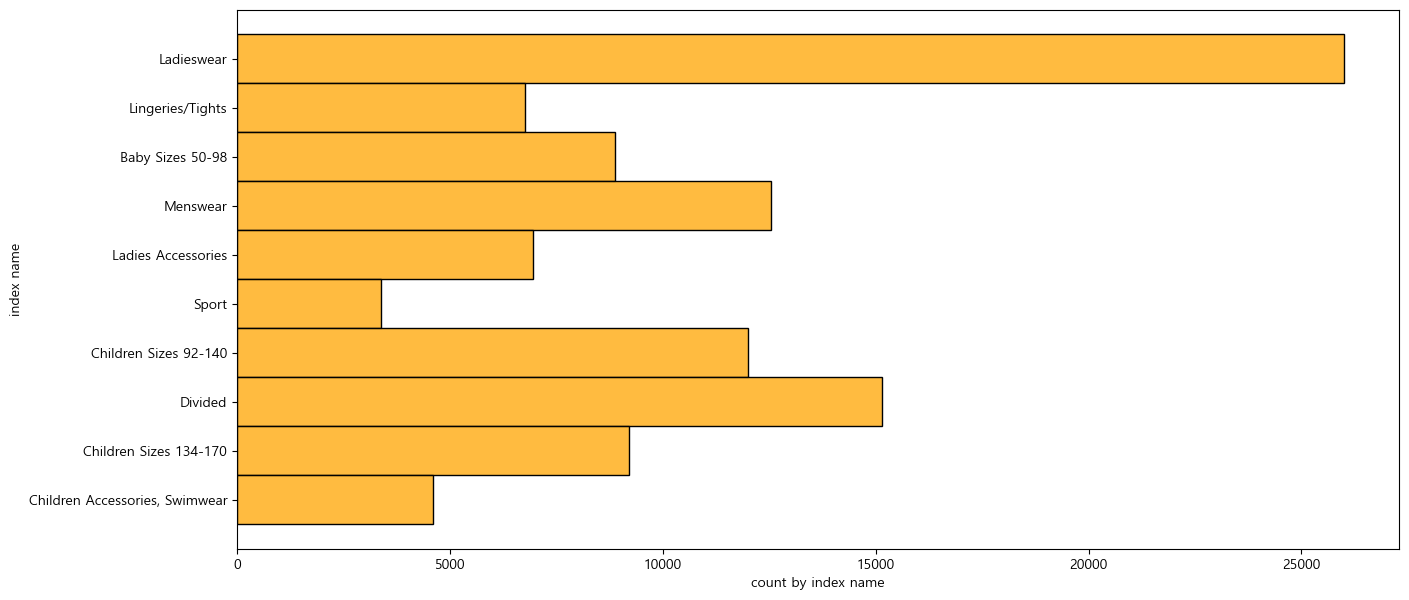

In [91]:
# 카테고리 분포
f, ax = plt.subplots(figsize=(15, 7))
ax = sns.histplot(data=articles, y='index_name', color='orange')
ax.set_xlabel('count by index name')
ax.set_ylabel('index name')
plt.show()

In [92]:
customers['age'].mean()

np.float64(36.386964565794)

In [93]:
# 상품 그룹(종류)별 수량
articles.groupby(['index_group_name', 'index_name']).count()['article_id']

index_group_name  index_name                    
Baby/Children     Baby Sizes 50-98                   8875
                  Children Accessories, Swimwear     4615
                  Children Sizes 134-170             9214
                  Children Sizes 92-140             12007
Divided           Divided                           15149
Ladieswear        Ladies Accessories                 6961
                  Ladieswear                        26001
                  Lingeries/Tights                   6775
Menswear          Menswear                          12553
Sport             Sport                              3392
Name: article_id, dtype: int64

In [94]:
# 상품 그룹,종류별 수량
pd.options.display.max_rows = None
articles.groupby(['product_group_name', 'product_type_name']).count()['article_id']

product_group_name     product_type_name       
Accessories            Accessories set                 7
                       Alice band                      6
                       Baby Bib                        3
                       Bag                          1280
                       Beanie                         56
                       Belt                          458
                       Bracelet                      180
                       Braces                          3
                       Bucket hat                      7
                       Cap                            13
                       Cap/peaked                    573
                       Dog Wear                       20
                       Earring                      1159
                       Earrings                       11
                       Eyeglasses                      2
                       Felt hat                       10
                       Giftbox          

---

### <center> 4. 피처 엔지니어링

---

- Offline_Affinity (오프라인 친밀도): `sales_channel_id` 가 1이면 오프라인, 2면 온라인 /  오프라인 구매 비중이 높은 유저를 찾아 팝업 타겟팅 우선순위를 부여하는 피처

- Style_Persona (스타일 페르소나): `index_group_name`이나 `perceived_colour_master_name` 을 활용해 유저가 '무채색 모던'파인지 '비비드 캐주얼'파인지 분류하는 피처

In [95]:
# 고객별 총 구매액 및 선호 채널 용도 DF
# customer_stats = transactions.groupby('customer_id').agg({
#     'price': 'sum', # 총 구매액
#     'sales_channel_id': lambda x: (x == 1).mean(), # 오프라인 구매 비중 계산 (1이면 OFF / 2면 ON / == 1의 비율확인)
#     'article_id': 'count' # 총 구매 횟수
# }).rename(columns={'price': 'total_spend', 'sales_channel_id': 'offline_ratio', 'article_id': 'purchase_count'})

# # 상권 매핑을 위한 고객 연령대 그룹화 --> 팝업 타겟팅용도 --> 
# customers['age_group'] = pd.cut(customers['age'], bins=[0, 19, 29, 39, 49, 99], labels=['Teen', '20s', '30s', '40s', '50+'])

In [96]:
customers['age_group'].value_counts()

age_group
20    528358
50    317992
30    234068
40    204118
10     71583
Name: count, dtype: int64

In [97]:
# customers['age_group'].value_counts()

- User Segmentation: 구매 금액($Monetary$), 구매 빈도($Frequency$), 오프라인 선호도 기반 타겟 그룹화.

---

### <center> 5. 파일 저장

---

In [98]:
# 전처리 파일 저장 (parquet)
# df.to_parquet('H&M merge.parquet', engine='pyarrow', compression='snappy', index=False)

# p rint(f'=== 최종 파일저장 확인 ===')